In [1]:
# 必要パッケージ
!pip install datasets==3.6.0
!pip install elasticsearch-haystack

In [2]:
# SubjQA のサブセット確認
from datasets import get_dataset_config_names

domains = get_dataset_config_names("subjqa")
domains

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


['books', 'electronics', 'grocery', 'movies', 'restaurants', 'tripadvisor']

In [3]:
# Electronics ドメインのデータロード
from datasets import load_dataset

subjqa = load_dataset("subjqa", name="electronics")

In [4]:
# answers 確認
print(subjqa["train"]["answers"][1])

{'text': ['Bass is weak as expected', 'Bass is weak as expected, even with EQ adjusted up'], 'answer_start': [1302, 1302], 'answer_subj_level': [1, 1], 'ans_subj_score': [0.5083333253860474, 0.5083333253860474], 'is_ans_subjective': [True, True]}


In [5]:
# pd に変換
import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}

for split, df in dfs.items():
  print(f"Number of questions in {split}: {df['id'].nunique()}")

Number of questions in train: 1295
Number of questions in test: 358
Number of questions in validation: 255


In [6]:
# ランダムにサンプリング
qa_cols = ["title", "question", "answers.text",
           "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 star...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro batt...


In [7]:
# 開始インデックスとアンサー長を使って、レビューから回答を抽出
start_idx = sample_df["answers.answer_start"].iloc[0][0]
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0])
sample_df["context"].iloc[0][start_idx:end_idx]

'this keyboard is compact'

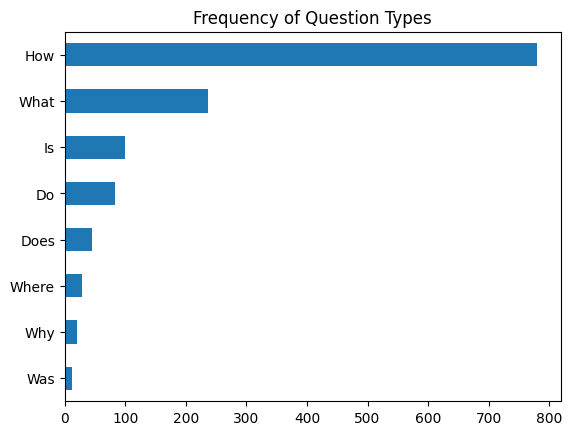

In [8]:
# 質問の種類を確認
from matplotlib import pyplot as plt
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
  counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]

pd.Series(counts).sort_values().plot.barh()
plt.title("Frequency of Question Types")
plt.show()

In [9]:
# 例を見てみる
for question_type in ["How", "What", "Is"]:
  for question in (
      dfs["train"][dfs["train"].question.str.startswith(question_type)]
      .sample(n=3, random_state=42)['question']):
    print(question)

How is the camera?
How do you like the control?
How fast is the charger?
What is direction?
What is the quality of the construction of the bag?
What is your impression of the product?
Is this how zoom works?
Is sound clear?
Is it a wireless keyboard?


In [10]:
# ベースモデルのトークナイザーロード
from transformers import AutoTokenizer

model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [11]:
# サンプルをトークン化
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \
file size."""
inputs = tokenizer(question, context, return_tensors="pt")
print(inputs) # input_ids, token_type_ids, attention_mask からなる

{'input_ids': tensor([[  101,  2129,  2172,  2189,  2064,  2023,  2907,  1029,   102,  2019,
         23378,  2003,  2055,  1015, 16914,  1013,  3371,  1010,  2061,  2055,
         25961,  2847,  5834,  2006,  5371,  2946,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1]])}


In [12]:
# input_ids をデコード
print(tokenizer.decode(inputs["input_ids"][0]))

[CLS] how much music can this hold? [SEP] an mp3 is about 1 mb / minute, so about 6000 hours depending on file size. [SEP]


In [13]:
# 質問応答ヘッド
import torch
from transformers import AutoModelForQuestionAnswering

model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)

with torch.no_grad():
  outputs = model(**inputs)
print(outputs)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: deepset/minilm-uncased-squad2
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-0.9862, -4.7750, -5.4025, -5.2378, -5.2863, -5.5117, -4.9819, -6.1880,
         -0.9862,  0.2596, -0.2144, -1.7136,  3.7806,  4.8561, -1.0546, -3.9097,
         -1.7374, -4.5944, -1.4278,  3.9949,  5.0391, -0.2018, -3.0193, -4.8549,
         -2.3107, -3.5110, -3.5713, -0.9862]]), end_logits=tensor([[-0.9623, -5.4733, -5.0326, -5.1639, -5.4278, -5.5151, -5.1749, -4.6233,
         -0.9623, -3.7855, -0.8715, -3.7745, -3.0162, -1.1780,  0.1758, -2.7365,
          4.8934,  0.3046, -3.1761, -3.2762,  0.8937,  5.6606, -0.3623, -4.9554,
         -3.2531, -0.0914,  1.6211, -0.9623]]), hidden_states=None, attentions=None)


In [14]:
# 開始/終了のロジット取得
start_logits = outputs.start_logits
end_logits = outputs.end_logits

In [15]:
# ロジットの形状確認 (全て[1, 28])
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")

Input IDs shape: torch.Size([1, 28])
Start logits shape: torch.Size([1, 28])
End logits shape: torch.Size([1, 28])


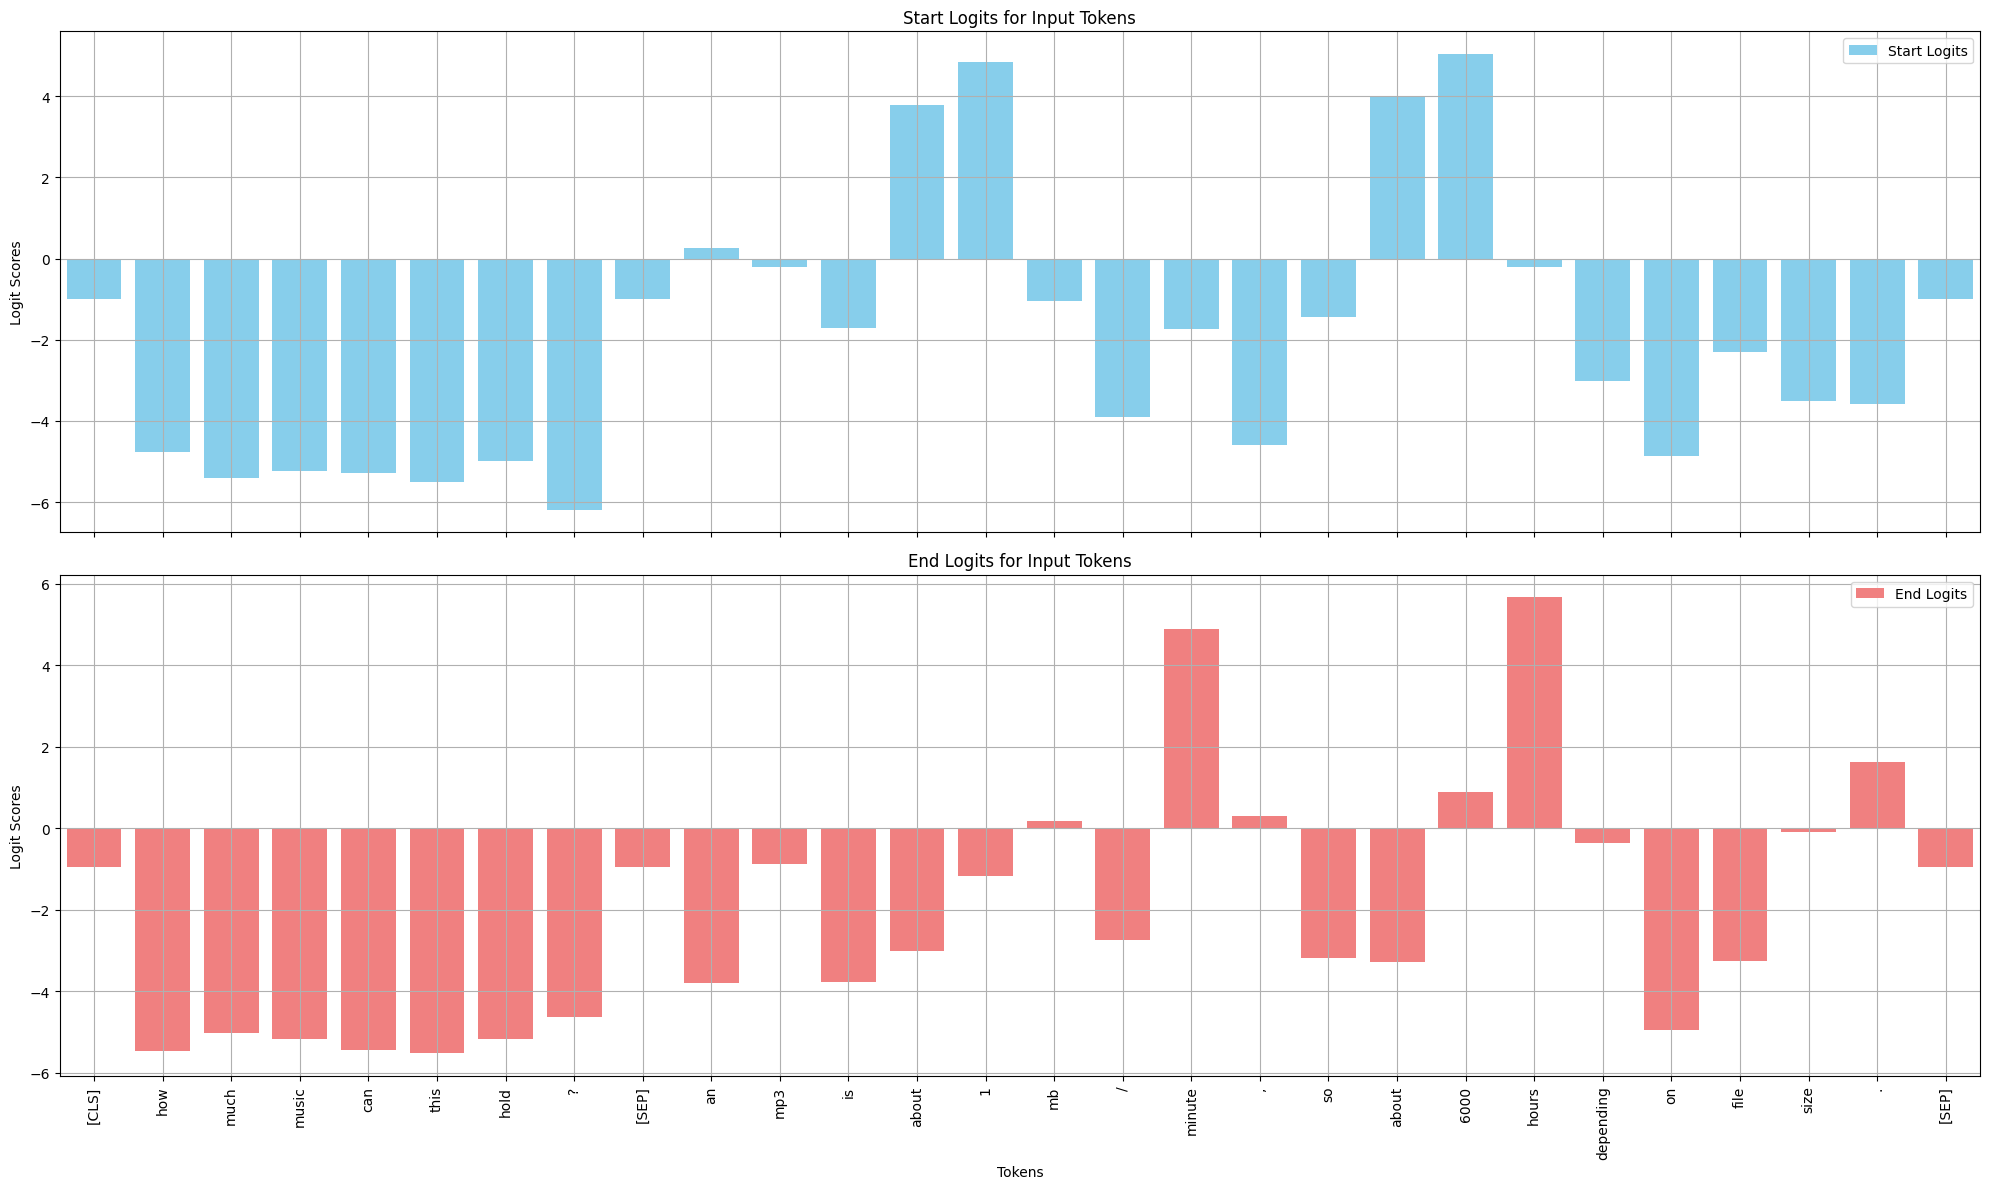

In [16]:
# ロジットを描画
import matplotlib.pyplot as plt
import numpy as np

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
start_scores = start_logits[0].detach().cpu().numpy()
end_scores = end_logits[0].detach().cpu().numpy()

x = np.arange(len(tokens))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

ax1.bar(x, start_scores, label="Start Logits", color="skyblue", width=0.8)
ax1.set_title("Start Logits for Input Tokens")
ax1.set_ylabel("Logit Scores")
ax1.legend()
ax1.grid(True)
ax1.set_xlim([-0.5, len(tokens) - 0.5])

ax2.bar(x, end_scores, label="End Logits", color="lightcoral", width=0.8)
ax2.set_title("End Logits for Input Tokens")
ax2.set_xlabel("Tokens")
ax2.set_ylabel("Logit Scores")
ax2.legend()
ax2.grid(True)
ax2.set_xticks(x)
ax2.set_xticklabels(tokens, rotation=90)
ax2.set_xlim([-0.5, len(tokens) - 0.5])

plt.tight_layout()
plt.show()

In [17]:
# argmax をとって回答を取得
start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits)+1
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"Question: {question}")
print(f"Anser: {answer}")

Question: How much music can this hold?
Anser: 6000 hours


In [18]:
# question-answering で pipeline 化
from transformers import pipeline

pipe = pipeline("question-answering", model=model, tokenizer=tokenizer) # v5 では非推奨
pipe(question=question, context=context, topk=3)

{'score': 0.26516249775886536, 'start': 38, 'end': 48, 'answer': '6000 hours'}

In [19]:
# 回答不可能な質問 (start, end ともに [CLS] が返ってきて欲しいが、[SEP] になってしまう)
pipe(question="Why is there no data?", context=context,
     handle_impossible_anser=True)

{'score': 0.0002626462373882532,
 'start': 16,
 'end': 71,
 'answer': '1 MB/minute, so about 6000 hours depending on file size'}

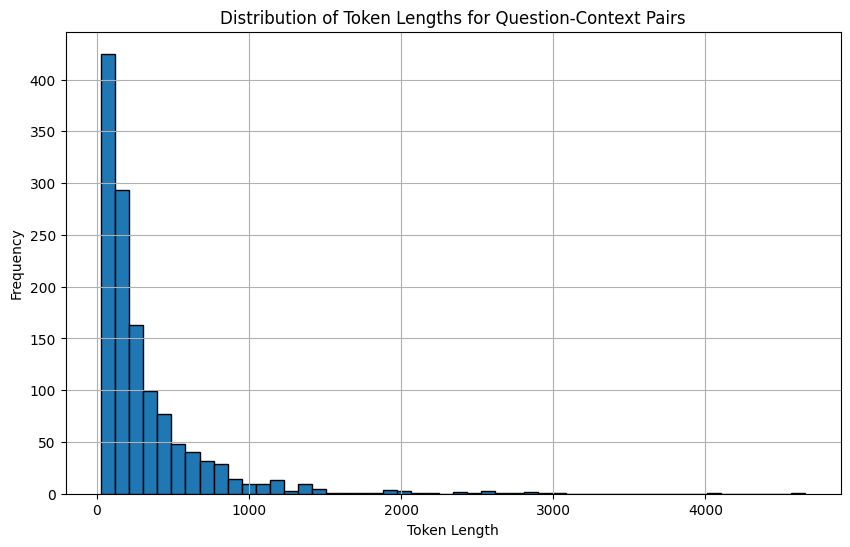

In [20]:
# SubjQA における質問・コンテキストペアのトークン分布
token_lengths = []

for _, row in dfs["train"].iterrows():
    question = row["question"]
    context = row["context"]
    inputs = tokenizer(question, context, truncation=True)
    token_lengths.append(len(inputs["input_ids"]))

plt.figure(figsize=(10, 6))
plt.hist(token_lengths, bins=50, edgecolor='black')
plt.title('Distribution of Token Lengths for Question-Context Pairs')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [21]:
# スライディングウィンドウの適用例
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(example["question"], example["context"],
                             return_overflowing_tokens=True, max_length=100,
                             stride=25)

# トークン数の確認
for idx, window in enumerate(tokenized_example["input_ids"]):
  print(f"Window #{idx} has {len(window)} tokens")

# デコード
for window in tokenized_example["input_ids"]:
  print(f"{tokenizer.decode(window)} \n")

Window #0 has 100 tokens
Window #1 has 88 tokens
[CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and qz - 99. the koss portapro is portable and has great bass response. the work great with my android phone and can be " rolled up " to be carried in my motorcycle jacket or computer bag without getting crunched. they are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is [SEP] 

[CLS] how is the bass? [SEP] and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is night and day better than any ear - bud could be and are almost as good as the pro 4aa. they are " open air " headphones so you cannot match the bass to the sealed types, but it comes close. for $ 32, you cannot go wrong. [SEP] 



In [22]:
# Elasticsearch ダウンロード
url = "https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-oss-7.9.2-linux-x86_64.tar.gz"
!wget -nc -q {url}
!tar -xzf elasticsearch-oss-7.9.2-linux-x86_64.tar.gz

In [23]:
# Elasticsearch 起動
import os
from subprocess import Popen, PIPE, STDOUT

# バックグラウンドプロセスとして実行
!chown -R daemon:daemon elasticsearch-7.9.2
es_server = Popen(args=['elasticsearch-7.9.2/bin/elasticsearch'],
                  stdout=PIPE, stderr=STDOUT, preexec_fn=lambda: os.setuid(1))
# 起動まで待機
!sleep 30

In [24]:
# Elasticsearch サーバーと通信テスト
## pretty=true が特殊な模様
## 公式APIドキュメント：https://www.elastic.co/docs/reference/elasticsearch/rest-apis/common-options
!curl -X GET "localhost:9200/?pretty"

{
  "name" : "61dd099f98fe",
  "cluster_name" : "elasticsearch",
  "cluster_uuid" : "FS3jrK9kSHOvU08ZWQEm6Q",
  "version" : {
    "number" : "7.9.2",
    "build_flavor" : "oss",
    "build_type" : "tar",
    "build_hash" : "d34da0ea4a966c4e49417f2da2f244e3e97b4e6e",
    "build_date" : "2020-09-23T00:45:33.626720Z",
    "build_snapshot" : false,
    "lucene_version" : "8.6.2",
    "minimum_wire_compatibility_version" : "6.8.0",
    "minimum_index_compatibility_version" : "6.0.0-beta1"
  },
  "tagline" : "You Know, for Search"
}


In [3]:
# ドキュメントストアのインスタンス化
from haystack_integrations.document_stores.elasticsearch import ElasticsearchDocumentStore

# 文書埋め込みを返すようにしておく
document_store = ElasticsearchDocumentStore(return_embedding=True)